# Exploratory Data Analysis — Predicting Smartphone Addiction

Kaggle Playground Series S6E8. This notebook explores the training data to understand
feature distributions, missingness, and relationships with the target (`addicted_label`)
before modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print(f"train shape: {train.shape}")
print(f"test shape:  {test.shape}")
train.head()

train shape: (691369, 14)
test shape:  (296302, 13)


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


## 1. Data types & basic structure

In [2]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [3]:
NUM_COLS = [
    "age", "daily_screen_time_hours", "social_media_hours", "gaming_hours",
    "work_study_hours", "sleep_hours", "notifications_per_day",
    "app_opens_per_day", "weekend_screen_time",
]
CAT_COLS = ["gender", "stress_level", "academic_work_impact"]
TARGET = "addicted_label"

train[NUM_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


## 2. Missing values

Every feature has meaningful missingness (5–20%). This is a defining characteristic of the
dataset and motivated including missing-value indicators as model features.

In [4]:
missing = pd.DataFrame({
    "train_missing_pct": train.isnull().mean().mul(100).round(2),
    "test_missing_pct": test.reindex(columns=train.columns).isnull().mean().mul(100).round(2),
}).drop(index=["id", TARGET], errors="ignore").sort_values("train_missing_pct", ascending=False)
missing

,train_missing_pct,test_missing_pct
social_media_hours,19.38,16.00
gaming_hours,18.34,20.05
weekend_screen_time,16.21,17.11
daily_screen_time_hours,13.86,11.07
app_opens_per_day,11.67,8.68
notifications_per_day,9.78,11.55
stress_level,7.98,6.62
work_study_hours,7.45,9.37
sleep_hours,6.43,7.58
academic_work_impact,6.40,8.68


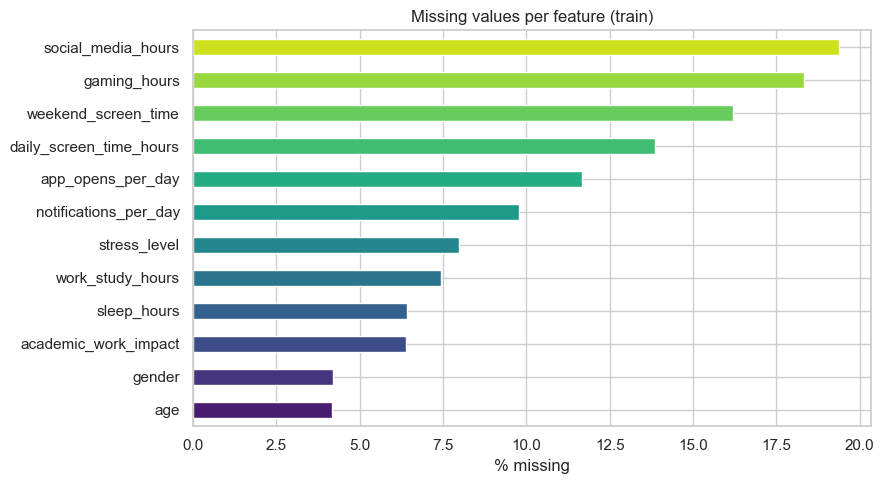

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
missing["train_missing_pct"].sort_values().plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(missing)))
ax.set_xlabel("% missing")
ax.set_title("Missing values per feature (train)")
plt.tight_layout()
plt.show()

## 3. Target distribution

The target is moderately imbalanced (~71% addicted / 29% not addicted), which is why
ROC-AUC (threshold-independent) is the right evaluation metric here.

addicted_label
0    0.290576
1    0.709424
Name: proportion, dtype: float64


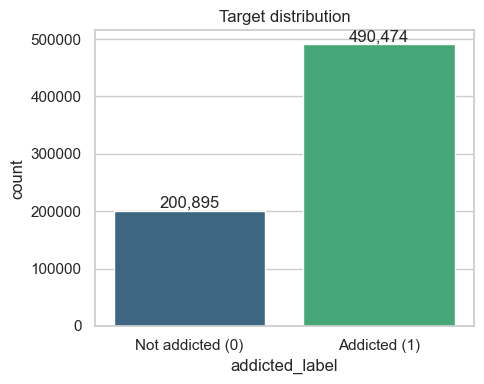

In [6]:
target_counts = train[TARGET].value_counts(normalize=True).sort_index()
print(target_counts)

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=train, x=TARGET, hue=TARGET, palette="viridis", legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Not addicted (0)", "Addicted (1)"])
ax.set_title("Target distribution")
for i, v in enumerate(train[TARGET].value_counts().sort_index()):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 4. Numeric feature distributions

Histograms of each numeric feature, split by target class, show which behaviors separate
addicted vs. non-addicted respondents.

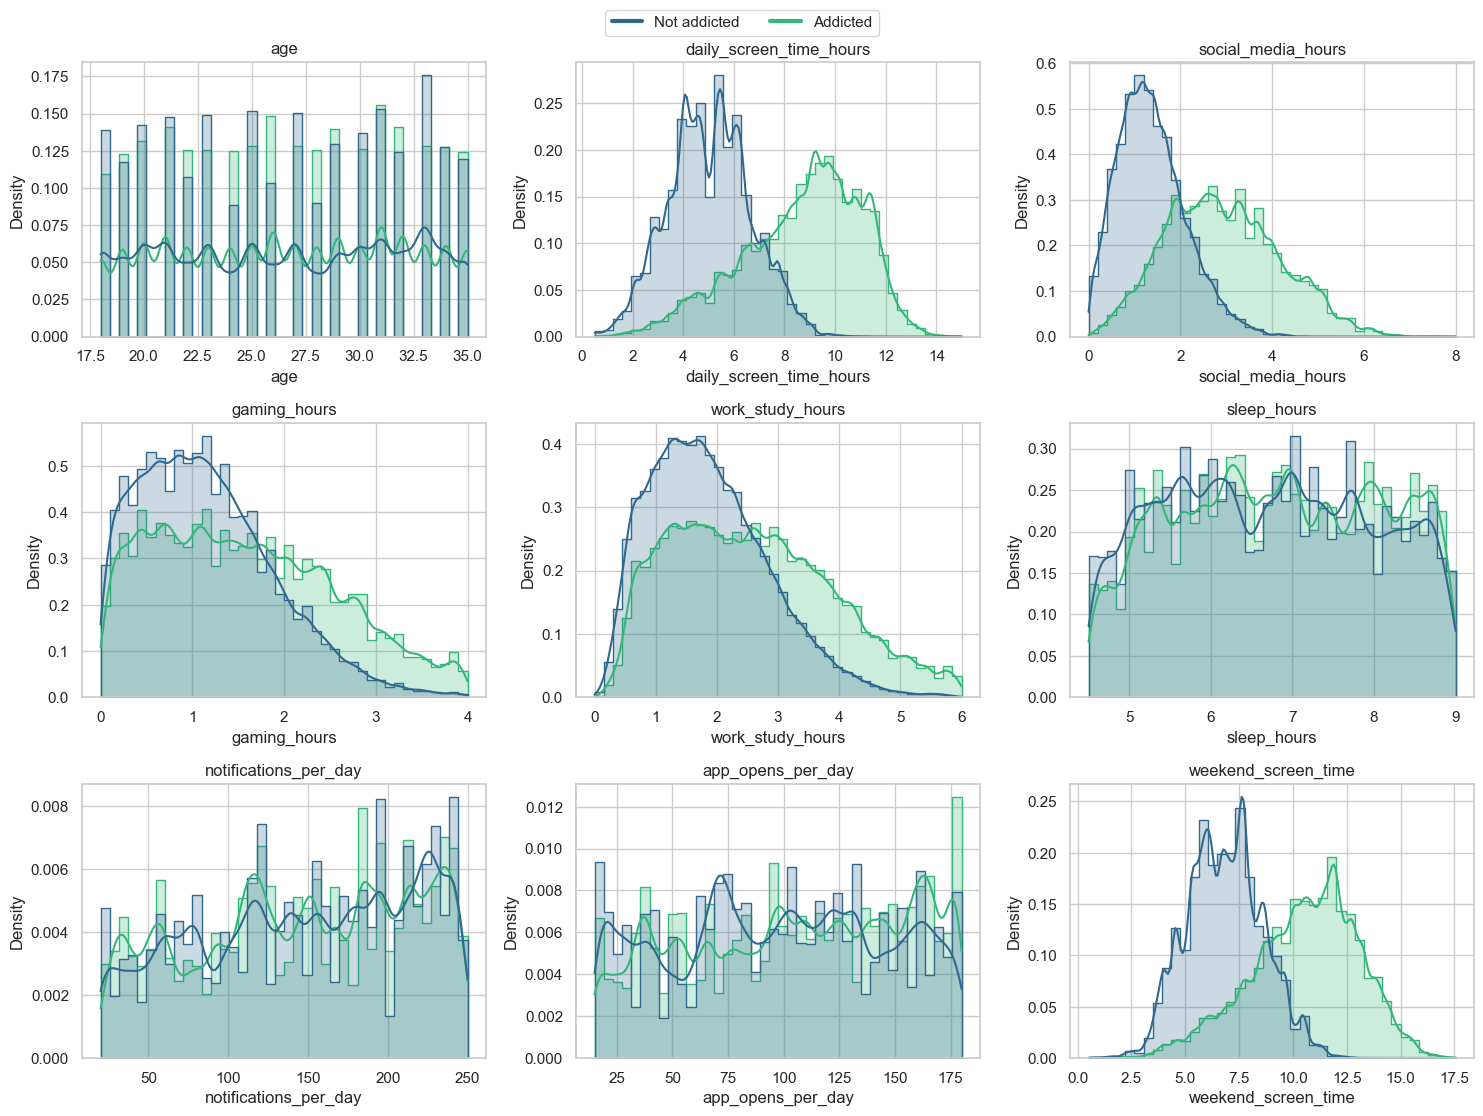

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.ravel(), NUM_COLS):
    sns.histplot(data=train, x=col, hue=TARGET, bins=40, kde=True,
                 palette="viridis", element="step", stat="density", common_norm=False, ax=ax)
    ax.set_title(col)
    ax.legend_ = None
handles = [plt.Line2D([0], [0], color=sns.color_palette("viridis", 2)[i], lw=3) for i in range(2)]
fig.legend(handles, ["Not addicted", "Addicted"], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.show()

**Observations:** `notifications_per_day`, `app_opens_per_day`, and `weekend_screen_time`
show the clearest separation between the two classes — addicted users skew noticeably higher
on all three, consistent with them being the top features by importance in the trained models.

## 5. Categorical feature distributions vs. target

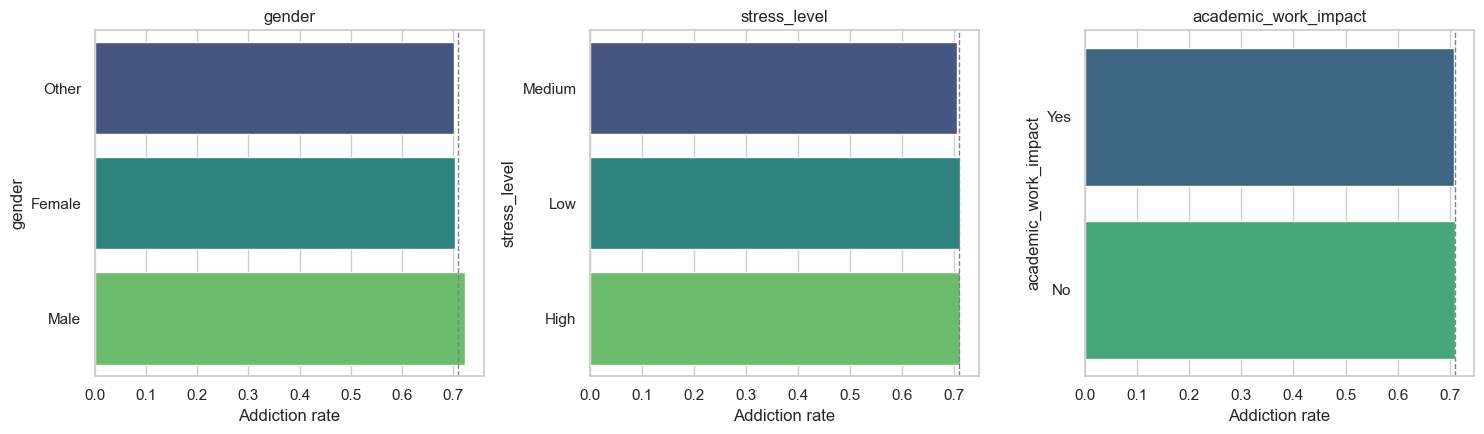

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, CAT_COLS):
    rate = train.groupby(col, observed=True)[TARGET].mean().sort_values()
    sns.barplot(x=rate.values, y=rate.index, hue=rate.index, palette="viridis", legend=False, ax=ax)
    ax.set_xlabel("Addiction rate")
    ax.set_title(col)
    ax.axvline(train[TARGET].mean(), color="grey", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

The dashed line marks the overall addiction rate (~70.9%). `stress_level` shows the
largest spread — higher stress correlates with a higher addiction rate — while `gender`
looks close to flat.

## 6. Does missingness itself carry signal?

In [9]:
rows = []
for col in NUM_COLS + CAT_COLS:
    is_missing = train[col].isnull()
    rows.append({
        "feature": col,
        "addiction_rate_when_present": train.loc[~is_missing, TARGET].mean(),
        "addiction_rate_when_missing": train.loc[is_missing, TARGET].mean(),
    })
missing_signal = pd.DataFrame(rows).set_index("feature")
missing_signal["gap"] = (missing_signal["addiction_rate_when_missing"]
                          - missing_signal["addiction_rate_when_present"])
missing_signal.sort_values("gap", key=abs, ascending=False)

,addiction_rate_when_present,addiction_rate_when_missing,gap
feature,,,
sleep_hours,0.709153,0.713377,0.004224
age,0.709251,0.713402,0.004151
app_opens_per_day,0.708980,0.712787,0.003807
daily_screen_time_hours,0.709122,0.711301,0.002178
weekend_screen_time,0.709187,0.710654,0.001467
gaming_hours,0.709182,0.710505,0.001324
work_study_hours,0.709326,0.710645,0.001319
notifications_per_day,0.709336,0.710242,0.000906
gender,0.709452,0.708790,-0.000662


Missingness is essentially uncorrelated with the target (gaps are all near zero), so it
looks Missing-At-Random rather than an informative signal on its own — including missing
indicators mainly helps the trees route around imputation artifacts rather than exploit a
real pattern.

## 7. Correlation among numeric features

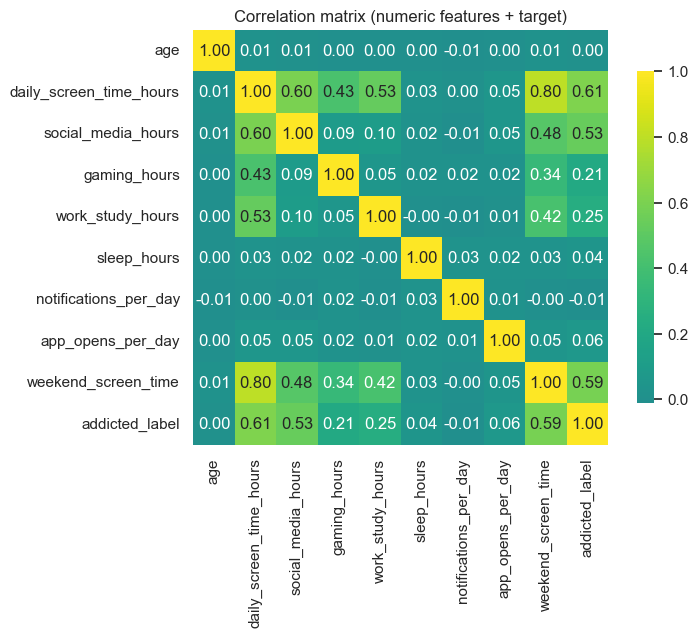

In [10]:
corr = train[NUM_COLS + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", center=0, square=True,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation matrix (numeric features + target)")
plt.tight_layout()
plt.show()

No pair of raw numeric features is strongly correlated with each other (little
multicollinearity risk), and individually each has only a weak linear correlation with the
target — the signal is spread across many features and their interactions, which is why
tree ensembles (which capture nonlinear interactions) outperform linear baselines here.

## 8. Feature vs. target — boxplots for the strongest signals

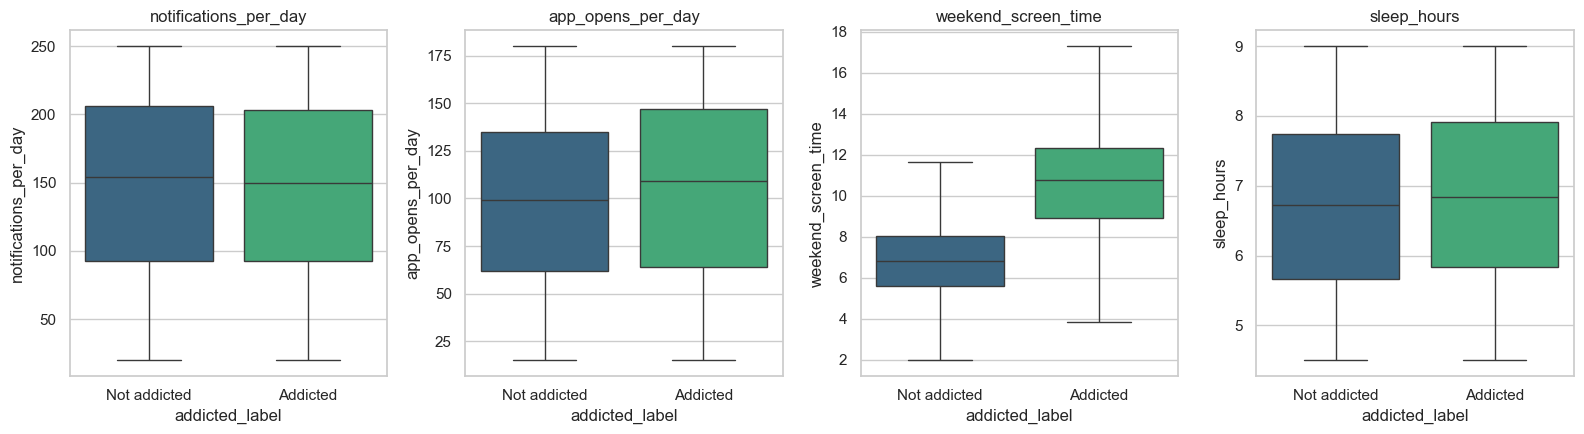

In [11]:
top_features = ["notifications_per_day", "app_opens_per_day", "weekend_screen_time", "sleep_hours"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, col in zip(axes, top_features):
    sns.boxplot(data=train, x=TARGET, y=col, hue=TARGET, palette="viridis", legend=False,
                showfliers=False, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Not addicted", "Addicted"])
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 9. Summary of key EDA findings

- **~700K rows, 9 numeric + 3 categorical features**, all with 5–20% missing values (looks
  Missing-At-Random — missingness itself doesn't predict the target).
- **Target is imbalanced** (~71% addicted / 29% not), matching ROC-AUC as the competition metric.
- **Usage-intensity features carry the most signal**: `notifications_per_day`,
  `app_opens_per_day`, and `weekend_screen_time` show the clearest separation between classes.
- **`stress_level` matters among categoricals**; `gender` shows little difference in addiction
  rate.
- **Low multicollinearity** among numeric features — no redundant pairs to drop, and the
  fairly weak individual correlations with the target suggest interactions/nonlinearities
  matter, favoring gradient-boosted trees over linear models.

These findings directly informed the feature engineering in `scripts/train_ensemble.py`
(missingness indicators, usage ratios, weekday/weekend deltas) and the choice of LightGBM /
XGBoost as the modeling approach.